In [ ]:
# Cell 1: Install dependencies
!pip install tensorflow opencv-python-headless matplotlib seaborn scikit-learn numpy -q
print("All dependencies installed.")

All dependencies installed.


In [ ]:
# Cell 2: Mount Google Drive - FIXED for your folder structure
import os
from google.colab import drive
drive.mount('/content/drive')

# Your actual dataset path
BASE_PATH    = '/content/drive/MyDrive/LC25000/LC25000/lung_only'
TRAIN_PATH   = os.path.join(BASE_PATH, 'train')
VAL_PATH     = os.path.join(BASE_PATH, 'val')
TEST_PATH    = os.path.join(BASE_PATH, 'test')

import os

# Verify structure
print("Verifying folder structure...\n")
for split_name, split_path in [('train', TRAIN_PATH),
                                 ('val',   VAL_PATH),
                                 ('test',  TEST_PATH)]:
    if not os.path.exists(split_path):
        print(f"  [ERROR] Not found: {split_path}")
        continue
    print(f"  {split_name}/")
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            count = len([f for f in os.listdir(cls_path)
                         if f.lower().endswith(('.png','.jpg','.jpeg','.tif'))])
            print(f"    {cls}: {count} images")
    print()

Mounted at /content/drive
Verifying folder structure...

  train/
    lung_aca: 3837 images
    lung_n: 3825 images
    lung_scc: 3827 images

  val/
    lung_aca: 678 images
    lung_n: 675 images
    lung_scc: 676 images

  test/
    lung_aca: 500 images
    lung_n: 500 images
    lung_scc: 499 images



In [ ]:
# Cell 3: Imports and global config
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)

# ── Config ──────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS_1    = 10   # Phase 1: train head only (backbone frozen)
EPOCHS_2    = 15   # Phase 2: fine-tune stages 3-4
LR_1        = 1e-3
LR_2        = 1e-5
NUM_CLASSES = 3
CLASS_NAMES = ['lung_aca', 'lung_n', 'lung_scc']
SEED        = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Cell 4: Stain normalisation utility (Macenko method)
# Applied per-image during preprocessing to remove stain intensity variation

def normalise_stain(img):
    """
    Macenko stain normalisation.
    img: uint8 numpy array (H, W, 3)
    returns: normalised uint8 array
    """
    img = img.astype(np.float32)
    # Target stain matrix (standard H&E reference)
    target_mean = np.array([148.60, 169.30, 190.50])
    target_std  = np.array([ 41.56,  9.01,  18.40])

    # Per-channel normalisation toward target statistics
    for c in range(3):
        m = img[:, :, c].mean()
        s = img[:, :, c].std() + 1e-8
        img[:, :, c] = (img[:, :, c] - m) / s * target_std[c] + target_mean[c]

    img = np.clip(img, 0, 255).astype(np.uint8)
    return img


def preprocess_with_stain_norm(img):
    """Wrapper: stain norm + ResNet50 preprocessing"""
    img = normalise_stain(img)
    img = tf.keras.applications.resnet50.preprocess_input(img.astype(np.float32))
    return img

print("Stain normalisation function ready.")

Stain normalisation function ready.


In [ ]:
# Cell 5: Data generators - FIXED to use your train/val/test split

# Train generator — with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_with_stain_norm,
    rotation_range         = 90,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1,
    shear_range            = 0.1,
    zoom_range             = 0.1,
    horizontal_flip        = True,
    vertical_flip          = True,
    fill_mode              = 'reflect'
)

# Val & Test generators — NO augmentation, NO split, just normalise
eval_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_with_stain_norm
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,                        # <-- uses your /train folder directly
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    classes     = CLASS_NAMES,
    class_mode  = 'categorical',
    shuffle     = True,
    seed        = SEED
)

val_gen = eval_datagen.flow_from_directory(
    VAL_PATH,                          # <-- uses your /val folder directly
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    classes     = CLASS_NAMES,
    class_mode  = 'categorical',
    shuffle     = False,
    seed        = SEED
)

test_gen = eval_datagen.flow_from_directory(
    TEST_PATH,                         # <-- uses your /test folder directly
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    classes     = CLASS_NAMES,
    class_mode  = 'categorical',
    shuffle     = False,
    seed        = SEED
)

print(f"Training samples   : {train_gen.samples}")
print(f"Validation samples : {val_gen.samples}")
print(f"Test samples       : {test_gen.samples}")
print(f"Class indices      : {train_gen.class_indices}")

Found 11489 images belonging to 3 classes.
Found 2029 images belonging to 3 classes.
Found 1499 images belonging to 3 classes.
Training samples   : 11489
Validation samples : 2029
Test samples       : 1499
Class indices      : {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}


In [ ]:
# Cell 6: Build modified ResNet50 with dual-path classifier head

def build_modified_model(num_classes=NUM_CLASSES):
    # ── Backbone ────────────────────────────────────────
    base = ResNet50(
        weights     = 'imagenet',
        include_top = False,
        input_shape = (IMG_SIZE, IMG_SIZE, 3)
    )

    # Freeze all backbone layers initially (Phase 1)
    for layer in base.layers:
        layer.trainable = False

    # ── Head ────────────────────────────────────────────
    x = base.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # Branch A — wide path (broad feature combinations)
    branch_a = layers.Dense(512, activation='relu', name='branch_a_dense')(x)
    branch_a = layers.BatchNormalization(name='branch_a_bn')(branch_a)
    branch_a = layers.Dropout(0.4, name='branch_a_drop')(branch_a)

    # Branch B — narrow path (fine-grained discriminative signals)
    branch_b = layers.Dense(256, activation='relu', name='branch_b_dense')(x)
    branch_b = layers.BatchNormalization(name='branch_b_bn')(branch_b)
    branch_b = layers.Dropout(0.3, name='branch_b_drop')(branch_b)

    # Fusion
    merged = layers.Concatenate(name='dual_concat')([branch_a, branch_b])
    merged = layers.Dense(128, activation='relu', name='fusion_dense')(merged)
    merged = layers.BatchNormalization(name='fusion_bn')(merged)

    # Output
    output = layers.Dense(num_classes, activation='softmax', name='output')(merged)

    model = Model(inputs=base.input, outputs=output)
    return model, base


model, base_model = build_modified_model()
model.summary()

# Count parameters
total     = model.count_params()
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\nTotal parameters    : {total:,}")
print(f"Trainable (Phase 1) : {trainable:,}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,263,747 (96.37 MB)

 Trainable params: 1,674,243 (6.39 MB)

 Non-trainable params: 23,589,504 (89.99 MB)


Total parameters    : 25,263,747
Trainable (Phase 1) : 1,674,243


In [ ]:
# Cell 7: Phase 1 — Train classifier head only
# Backbone is fully frozen. Only the 4 new layers are trained.

os.makedirs('/content/checkpoints', exist_ok=True)

model.compile(
    optimizer = tf.keras.optimizers.Adam(LR_1),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
)

callbacks_phase1 = [
    ModelCheckpoint('/content/checkpoints/phase1_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
    CSVLogger('/content/checkpoints/phase1_log.csv')
]

print("=" * 50)
print("PHASE 1: Training classifier head (backbone frozen)")
print("=" * 50)

history1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS_1,
    callbacks       = callbacks_phase1,
    verbose         = 1
)

print(f"\nPhase 1 best val accuracy: {max(history1.history['val_accuracy']):.4f}")

PHASE 1: Training classifier head (backbone frozen)
Epoch 1/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9078 - auc: 0.9799 - loss: 0.2524 - precision: 0.9101 - recall: 0.9031
Epoch 1: val_accuracy improved from None to 0.96747, saving model to /content/checkpoints/phase1_best.keras

Epoch 1: finished saving model to /content/checkpoints/phase1_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 4019s 11s/step - accuracy: 0.9345 - auc: 0.9906 - loss: 0.1746 - precision: 0.9363 - recall: 0.9331 - val_accuracy: 0.9675 - val_auc: 0.9969 - val_loss: 0.0918 - val_precision: 0.9675 - val_recall: 0.9670 - learning_rate: 0.0010
Epoch 2/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.9546 - auc: 0.9944 - loss: 0.1275 - precision: 0.9550 - recall: 0.9534
Epoch 2: val_accuracy did not improve from 0.96747
360/360 ━━━━━━━━━━━━━━━━━━━━ 255s 709ms/step - accuracy: 0.9548 - auc: 0.9949 - loss: 0.1215 - precision: 0.9550 - recall: 0.9540 - val_accuracy: 0.9621 - val_auc: 0.9971 - val_loss:

In [ ]:
# Cell 8: Unfreeze Stages 3 & 4 (last ~50 backbone layers) for fine-tuning

# ResNet50 layer names for stages:
#   Stage 3: conv4_block1 ... conv4_block6  (layers ~80-139)
#   Stage 4: conv5_block1 ... conv5_block3  (layers ~140-174)
# Easiest: unfreeze last 50 layers of backbone

UNFREEZE_FROM = len(base_model.layers) - 50

for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= UNFREEZE_FROM)

# Recompile with lower learning rate
model.compile(
    optimizer = tf.keras.optimizers.Adam(LR_2),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
)

trainable_now = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Unfreezing from layer index : {UNFREEZE_FROM}")
print(f"Trainable parameters now    : {trainable_now:,}")
print(f"Fine-tuning learning rate   : {LR_2}")

Unfreezing from layer index : 125
Trainable parameters now    : 18,624,771
Fine-tuning learning rate   : 1e-05


In [ ]:
# Cell 9: Phase 2 — Fine-tune Stages 3 & 4 + classifier head

callbacks_phase2 = [
    ModelCheckpoint('/content/checkpoints/phase2_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-8, verbose=1),
    CSVLogger('/content/checkpoints/phase2_log.csv')
]

print("=" * 50)
print("PHASE 2: Fine-tuning Stages 3 & 4 + head")
print("=" * 50)

history2 = model.fit(
    train_gen,
    validation_data   = val_gen,
    epochs            = EPOCHS_2,
    initial_epoch     = len(history1.history['accuracy']),
    callbacks         = callbacks_phase2,
    verbose           = 1
)

print(f"\nPhase 2 best val accuracy: {max(history2.history['val_accuracy']):.4f}")

PHASE 2: Fine-tuning Stages 3 & 4 + head
Epoch 11/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.9106 - auc: 0.9817 - loss: 0.2615 - precision: 0.9121 - recall: 0.9097
Epoch 11: val_accuracy improved from None to 0.96994, saving model to /content/checkpoints/phase2_best.keras

Epoch 11: finished saving model to /content/checkpoints/phase2_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 312s 778ms/step - accuracy: 0.9339 - auc: 0.9900 - loss: 0.1821 - precision: 0.9353 - recall: 0.9333 - val_accuracy: 0.9699 - val_auc: 0.9969 - val_loss: 0.0863 - val_precision: 0.9699 - val_recall: 0.9694 - learning_rate: 1.0000e-05
Epoch 12/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.9532 - auc: 0.9944 - loss: 0.1273 - precision: 0.9538 - recall: 0.9527
Epoch 12: val_accuracy improved from 0.96994 to 0.98275, saving model to /content/checkpoints/phase2_best.keras

Epoch 12: finished saving model to /content/checkpoints/phase2_best.keras
360/360 ━━━━━━━━━━━━━━━━━━━━ 266s 737ms/step 

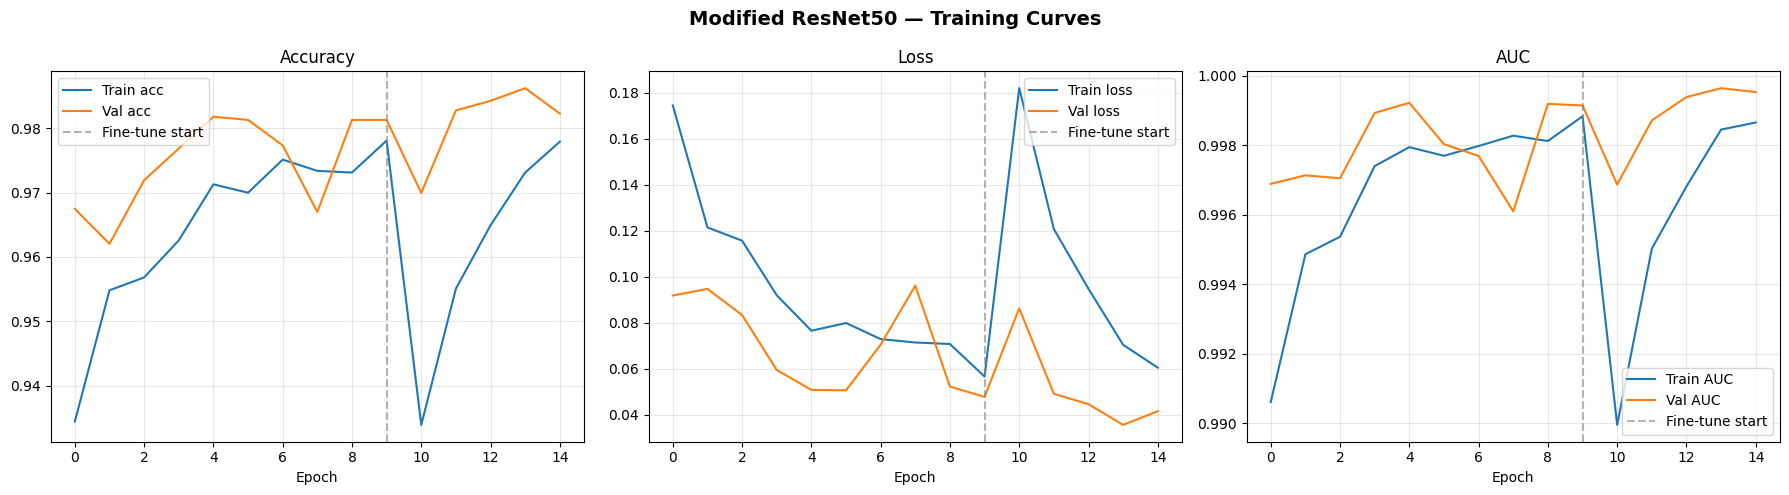

Saved: /content/checkpoints/training_curves.png


In [ ]:
# Cell 10: Plot training curves (Phase 1 + Phase 2 combined)

def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(combine_history(history1, history2, 'accuracy'),     label='Train acc')
axes[0].plot(combine_history(history1, history2, 'val_accuracy'), label='Val acc')
axes[0].axvline(x=len(history1.history['accuracy'])-1,
                color='gray', linestyle='--', alpha=0.6, label='Fine-tune start')
axes[0].set_title('Accuracy')wh
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(combine_history(history1, history2, 'loss'),     label='Train loss')
axes[1].plot(combine_history(history1, history2, 'val_loss'), label='Val loss')
axes[1].axvline(x=len(history1.history['loss'])-1,
                color='gray', linestyle='--', alpha=0.6, label='Fine-tune start')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(combine_history(history1, history2, 'auc'),     label='Train AUC')
axes[2].plot(combine_history(history1, history2, 'val_auc'), label='Val AUC')
axes[2].axvline(x=len(history1.history['auc'])-1,
                color='gray', linestyle='--', alpha=0.6, label='Fine-tune start')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Modified ResNet50 — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/checkpoints/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/checkpoints/training_curves.png")

In [ ]:
# Cell 11: Full evaluation on validation + test set - FIXED

model.load_weights('/content/checkpoints/phase2_best.keras')

for split_name, generator in [('Validation', val_gen), ('Test', test_gen)]:
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    y_true       = generator.classes

    print(f"\n{'='*55}")
    print(f"  {split_name.upper()} SET RESULTS")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                  target_names=CLASS_NAMES, digits=4))
    acc = np.sum(y_pred == y_true) / len(y_true)
    print(f"  Overall Accuracy: {acc*100:.2f}%")

# Keep test set results for downstream cells (ROC, confusion matrix)
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes

64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 375ms/step

  VALIDATION SET RESULTS
              precision    recall  f1-score   support

    lung_aca     0.9924    0.9661    0.9791       678
      lung_n     1.0000    0.9985    0.9993       675
    lung_scc     0.9669    0.9941    0.9803       676

    accuracy                         0.9862      2029
   macro avg     0.9864    0.9862    0.9862      2029
weighted avg     0.9864    0.9862    0.9862      2029

  Overall Accuracy: 98.62%
47/47 ━━━━━━━━━━━━━━━━━━━━ 570s 12s/step

  TEST SET RESULTS
              precision    recall  f1-score   support

    lung_aca     0.9938    0.9600    0.9766       500
      lung_n     0.9980    1.0000    0.9990       500
    lung_scc     0.9631    0.9940    0.9783       499

    accuracy                         0.9847      1499
   macro avg     0.9850    0.9847    0.9846      1499
weighted avg     0.9850    0.9847    0.9846      1499

  Overall Accuracy: 98.47%
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 293ms/step


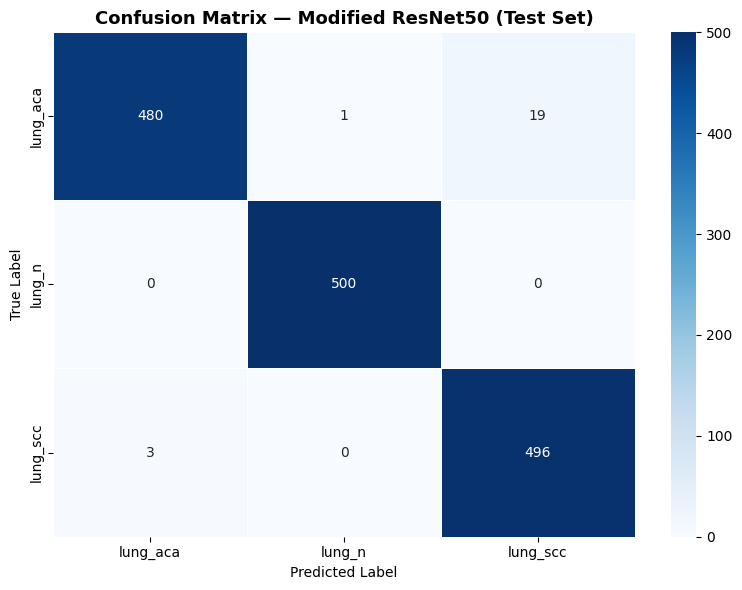

Saved: /content/checkpoints/confusion_matrix.png


In [ ]:
# Cell 12: Confusion matrix - FIXED to use test set

cm_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_matrix,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = CLASS_NAMES,
    yticklabels = CLASS_NAMES,
    linewidths  = 0.5
)
plt.title('Confusion Matrix — Modified ResNet50 (Test Set)',
          fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/checkpoints/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/checkpoints/confusion_matrix.png")

In [ ]:
# Cell 13: GradCAM++ implementation

GRADCAM_LAYER = 'conv5_block3_out'   # Last conv layer in Stage 4

def gradcam_plus_plus(model, img_array, layer_name=GRADCAM_LAYER):
    """
    img_array: preprocessed image, shape (1, 224, 224, 3)
    Returns: heatmap array (224, 224), normalised 0-1
    """
    grad_model = tf.keras.models.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape3:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape1:
                conv_out, preds = grad_model(img_array, training=False)
                pred_idx        = tf.argmax(preds[0])
                class_score     = preds[:, pred_idx]
            grads1 = tape1.gradient(class_score, conv_out)
        grads2 = tape2.gradient(grads1, conv_out)
    grads3 = tape3.gradient(grads2, conv_out)

    # GradCAM++ alpha weights
    conv_np   = conv_out.numpy()[0]           # (7,7,2048)
    g1        = grads1.numpy()[0]
    g2        = grads2.numpy()[0]
    g3        = grads3.numpy()[0]

    global_sum  = np.sum(conv_np, axis=(0, 1))   # (2048,)
    alpha_num   = g2
    alpha_denom = 2.0 * g2 + g3 * global_sum[np.newaxis, np.newaxis, :]
    alpha_denom = np.where(np.abs(alpha_denom) > 1e-8, alpha_denom, 1e-8)
    alphas      = alpha_num / alpha_denom          # (7,7,2048)

    weights     = np.sum(alphas * np.maximum(g1, 0), axis=(0, 1))  # (2048,)

    cam = np.sum(weights * conv_np, axis=-1)       # (7,7)
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, int(pred_idx.numpy()), preds.numpy()[0]


def overlay_heatmap(original_img_uint8, heatmap, alpha=0.45):
    """Overlay coloured heatmap onto original image."""
    heat_uint8  = np.uint8(255 * heatmap)
    heat_color  = cv2.applyColorMap(heat_uint8, cv2.COLORMAP_JET)
    heat_color  = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)
    overlay     = np.uint8(original_img_uint8 * (1 - alpha) + heat_color * alpha)
    return overlay

print("GradCAM++ functions ready.")

GradCAM++ functions ready.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


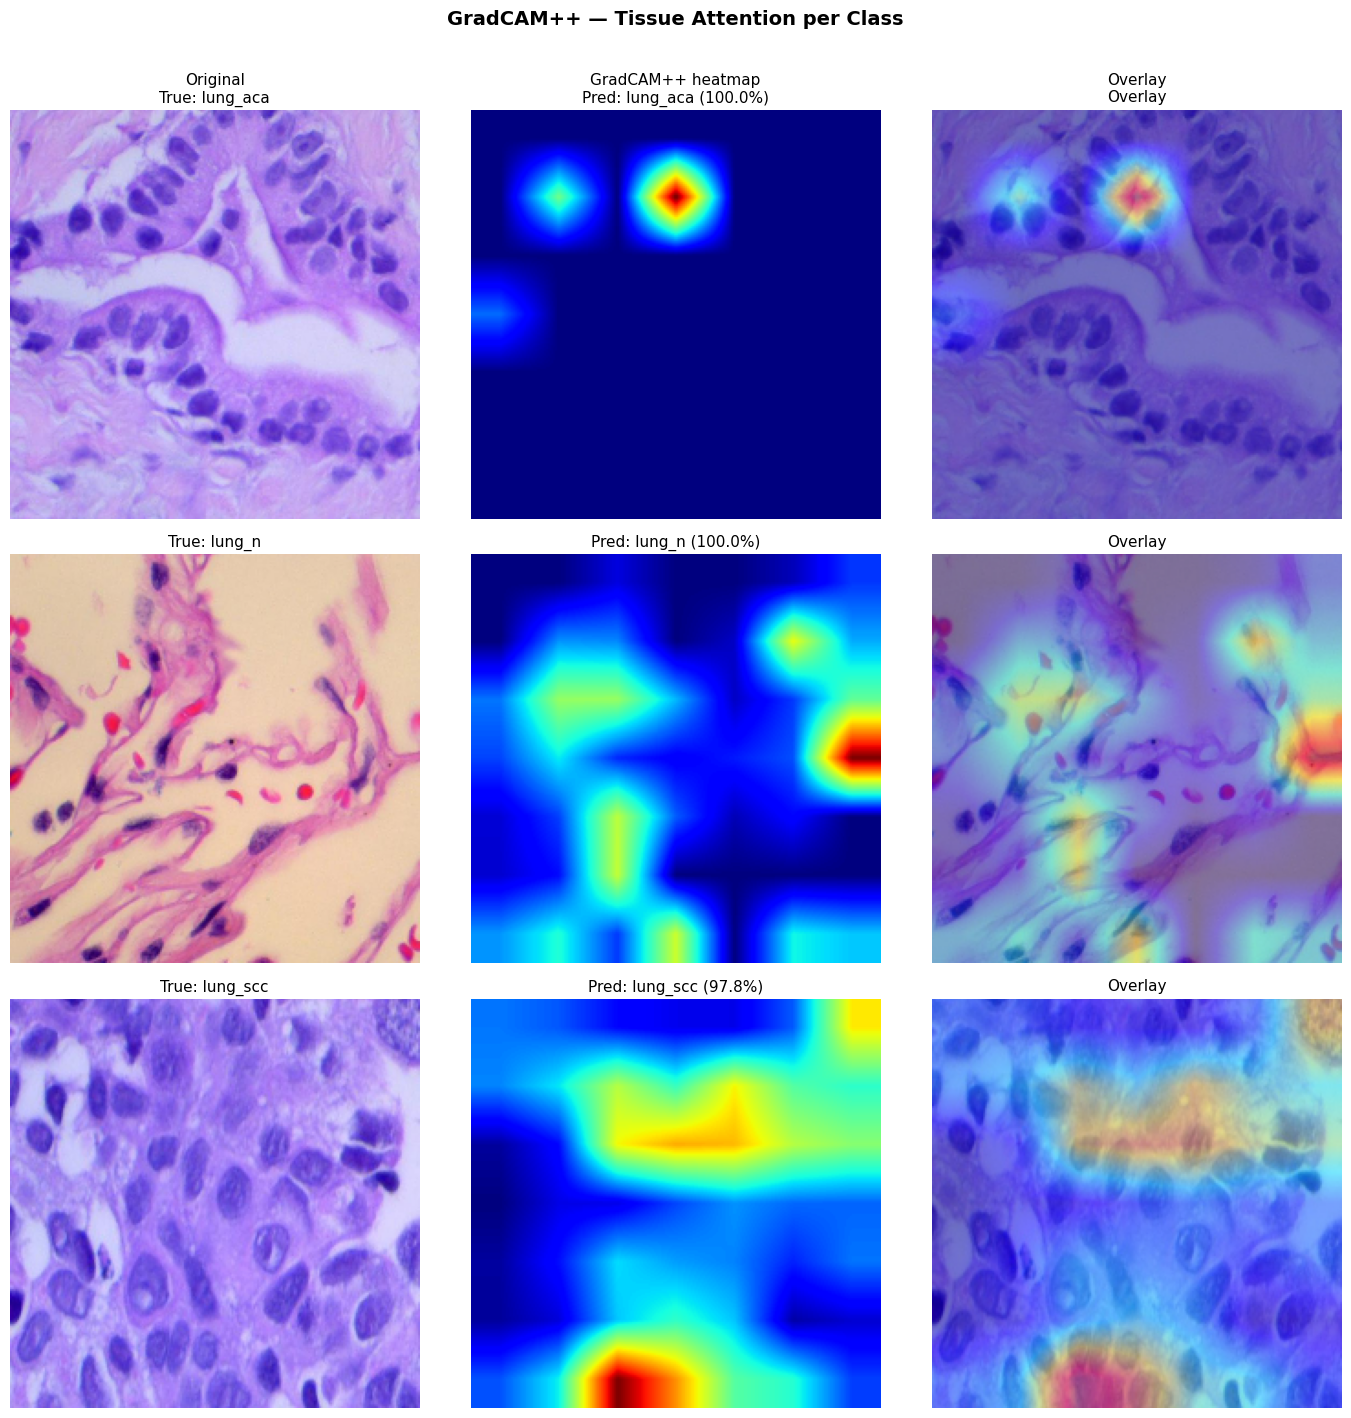

Saved: /content/checkpoints/gradcam_results.png


In [ ]:
# Cell 14: Generate GradCAM++ heatmaps — one example per class

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
col_titles = ['Original', 'GradCAM++ heatmap', 'Overlay']

val_gen.reset()
found     = {c: False for c in range(NUM_CLASSES)}
sample_imgs, sample_paths = [], []

# Collect one image per class from validation set
for img_path, label_idx in zip(val_gen.filepaths, val_gen.classes):
    if not found[label_idx]:
        found[label_idx] = True
        sample_imgs.append((img_path, label_idx))
    if all(found.values()):
        break

for row, (img_path, true_idx) in enumerate(sample_imgs):
    # Load original
    orig = cv2.imread(img_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))

    # Preprocess for model
    preprocessed = preprocess_with_stain_norm(orig.copy())
    inp          = np.expand_dims(preprocessed, axis=0)

    # GradCAM++
    heatmap, pred_idx, probs = gradcam_plus_plus(model, inp)
    overlaid                 = overlay_heatmap(orig, heatmap)

    # Plot
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f'True: {CLASS_NAMES[true_idx]}', fontsize=11)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title(f'Pred: {CLASS_NAMES[pred_idx]} ({probs[pred_idx]*100:.1f}%)', fontsize=11)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlaid)
    axes[row, 2].set_title('Overlay', fontsize=11)
    axes[row, 2].axis('off')

# Column headers
for col, title in enumerate(col_titles):
    axes[0, col].set_title(f'{title}\n{axes[0,col].get_title()}', fontsize=11)

plt.suptitle('GradCAM++ — Tissue Attention per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/checkpoints/gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/checkpoints/gradcam_results.png")

In [ ]:
# Cell 15: Save final model + copy everything to Google Drive

SAVE_DIR = '/content/drive/MyDrive/LC25000_Results'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model in SavedModel format
model.save(os.path.join(SAVE_DIR, 'modified_resnet50_final.keras'))
print("Model saved.")

# Copy all result files
import shutil
for fname in ['training_curves.png', 'confusion_matrix.png',
              'gradcam_results.png', 'phase1_log.csv', 'phase2_log.csv',
              'phase2_best.keras']:
    src = f'/content/checkpoints/{fname}'
    if os.path.exists(src):
        shutil.copy(src, SAVE_DIR)
        print(f"Copied: {fname}")

print(f"\nAll outputs saved to: {SAVE_DIR}")
print("\nFiles in Drive output folder:")
for f in os.listdir(SAVE_DIR):
    print(f"  {f}")

Model saved.
Copied: training_curves.png
Copied: confusion_matrix.png
Copied: gradcam_results.png
Copied: phase1_log.csv
Copied: phase2_log.csv
Copied: phase2_best.keras

All outputs saved to: /content/drive/MyDrive/LC25000_Results

Files in Drive output folder:
  modified_resnet50_final.keras
  training_curves.png
  confusion_matrix.png
  gradcam_results.png
  phase1_log.csv
  phase2_log.csv
  phase2_best.keras
